In [71]:
import numpy as np
import matplotlib.pyplot as plt

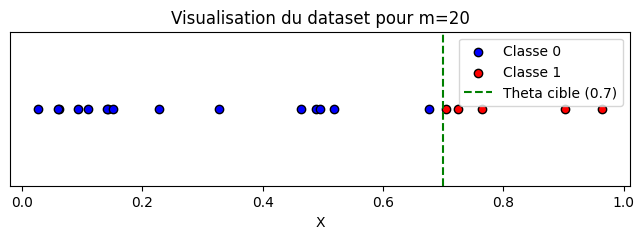

In [72]:
theta = 0.7 #theta compris entre 0 et 1
m_valeurs = [5,10,20,50,100,200]
datasets = {}

def generer_dataset(m,theta):
    """
    Génère le dataset
    """
    X = np.random.uniform(0,1,m)
    y = np.where(X> theta,1,0)
    return X,y

for m in m_valeurs:
    datasets[m] = generer_dataset(m,theta)


X_visu, y_visu = datasets[20]

plt.figure(figsize=(8, 2))
plt.scatter(X_visu[y_visu == 0], np.zeros(sum(y_visu == 0)), color='blue', label='Classe 0', edgecolor='k')
plt.scatter(X_visu[y_visu == 1], np.zeros(sum(y_visu == 1)), color='red', label='Classe 1', edgecolor='k')
plt.axvline(theta, color='green', linestyle='--', label=f'Theta cible ({theta})')

plt.title("Visualisation du dataset pour m=20")
plt.xlabel("X")
plt.yticks([]) 
plt.legend()
plt.show()







In [73]:
def calcul_erreur_empirique(X, y, theta):
    """
    Calcule l'erreur empirique  pour un seuil theta donné.
    """
    predictions = np.where(X > theta, 1, 0)
    erreur_empirique = np.mean(predictions != y)
    return erreur_empirique

def algorithme_ERM(X, y):
    """
    Implémente l'algorithme ERM pour trouver le seuil optimal.
    """
    X_trier = np.sort(np.unique(X))
    candidats = [0.0]
    for i in range(len(X_trier) - 1):
        millieu = (X_trier[i] + X_trier[i+1]) / 2.0
        candidats.append(millieu)
    candidats.append(1.0)
    
    meilleur_theta = candidats[0]
    min_erreur = float('inf')
    for theta in candidats:
        erreur = calcul_erreur_empirique(X, y, theta)
        if erreur < min_erreur:
            min_erreur = erreur
            meilleur_theta = theta
            
    return meilleur_theta, min_erreur

theta_erm, err_erm = algorithme_ERM(X_visu, y_visu)
print(f"Theta cible réel : {theta}")
print(f"Theta trouvé par ERM : {theta_erm:.4f}")
print(f"Erreur empirique  : {err_erm:.4f}")

Theta cible réel : 0.7
Theta trouvé par ERM : 0.6902
Erreur empirique  : 0.0000



Pour mettre en place l'algorithme ERM il faut suivre les 3 assumption du cours:
1.Classe d'hypothèse finie: 
    En theorie l'espace des seuils theta possibles sur [0,1] est infini .Dans mon code j'ai defini une liste de finie candidats.
    J'ai trié mes points et calculer le millieu entre chaque valeur et je ne teste que les seuils qui modifient concrètement les prédictions.
    Ainsi j'ai un nombre fini de candidats
2.Hypothese de réalisabilité:
    Cette hypothèse dit qu'il existe dans notre classe d'hypothèse un classifieur parfait qui a son erreur véritable a 0.
    Dans mon code, comme les données sont générées sans bruit par un vrai seuil, l'algorithme ERM trouve un seuil où l'erreur empirique atteint 0
3.Données indépendante et identicallement distribuées:
    L'algorithme suppose que les données d'entrainement ont été généré de manière inépendante a partir de la même distribution sous-jacente.
    Dans algorithme_ERM on reçoit un echantillon en entrée de taille m qui a été généréee via np.random.uniform(0, 1, m) qui garantit l'independance des données


Pour m =   5 | Erreur empirique: 0.0000 | Erreur vraie: 0.0422
Pour m =  10 | Erreur empirique: 0.0000 | Erreur vraie: 0.0816
Pour m =  20 | Erreur empirique: 0.0000 | Erreur vraie: 0.0107
Pour m =  50 | Erreur empirique: 0.0000 | Erreur vraie: 0.0038
Pour m = 100 | Erreur empirique: 0.0000 | Erreur vraie: 0.0057
Pour m = 200 | Erreur empirique: 0.0000 | Erreur vraie: 0.0017


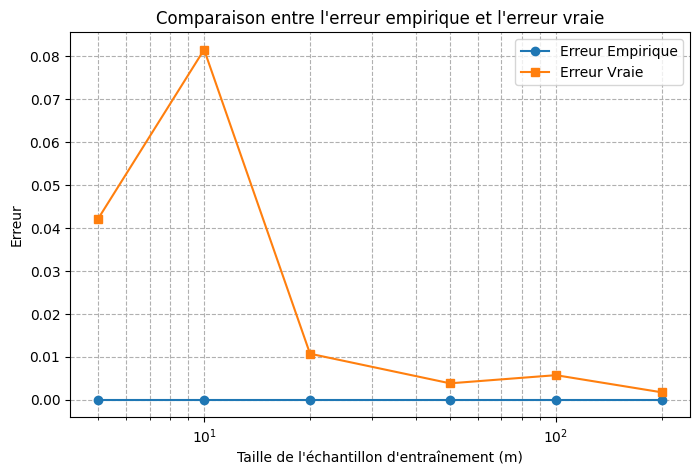

In [74]:

m_test = 10000
X_test, y_test = generer_dataset(m_test, theta)

erreurs_empiriques = {}
erreurs_veritable = {}

for m in m_valeurs:
    X_train, y_train = datasets[m]
    best_theta, emp_err = algorithme_ERM(X_train, y_train)
    erreurs_empiriques[m] = emp_err
    test_predictions = np.where(X_test > best_theta, 1, 0)
    true_err = np.mean(test_predictions != y_test)
    erreurs_veritable[m] = true_err
    
    print(f"Pour m = {m:3d} | Erreur empirique: {emp_err:.4f} | Erreur vraie: {true_err:.4f}")
    
plt.figure(figsize=(8, 5))
plt.plot(m_valeurs, [erreurs_empiriques[m] for m in m_valeurs], marker='o', label='Erreur Empirique')
plt.plot(m_valeurs, [erreurs_veritable[m] for m in m_valeurs], marker='s', label='Erreur Vraie ')
plt.xscale('log')
plt.xlabel("Taille de l'échantillon d'entraînement (m)")
plt.ylabel("Erreur")
plt.title("Comparaison entre l'erreur empirique et l'erreur vraie")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

L'erreur empirique  reste constante à 0 : Quelle que soit la taille de l'échantillon  l'algorithme ERM parvient à trouver un classifieur qui ne fait aucune erreur sur les données d'entraînement. Ceci est une conséquence directe de l'hypothèse de réalisabilité, qui garantit qu'un modèle parfait existe pour notre échantillon.  

L'erreur vraie  est initialement plus élevée : Pour les petits échantillons (par exemple m=5 ou m=10), l'erreur vraie est nettement supérieure à l'erreur empirique. L'algorithme subit un surapprentissage  car il sépare parfaitement les quelques points d'entraînement disponibles, mais ce seuil ne correspond pas exactement à la véritable règle sous-jacente.  

Convergence avec l'augmentation de m : L'écart de généralisation entre les deux erreurs se réduit drastiquement à mesure que la taille de l'échantillon d'entraînement augmente. L'erreur vraie chute et se rapproche de l'erreur empirique (0), illustrant que l'ERM généralise de mieux en mieux : une bonne performance sur un grand jeu d'entraînement implique une bonne performance sur des données non vues

Estimation de Pr(L(h) > 0.05) sur 500 répétitions :
m =   5 | Probabilité estimée : 0.6000
m =  10 | Probabilité estimée : 0.3500
m =  20 | Probabilité estimée : 0.1480
m =  50 | Probabilité estimée : 0.0060
m = 100 | Probabilité estimée : 0.0000
m = 200 | Probabilité estimée : 0.0000


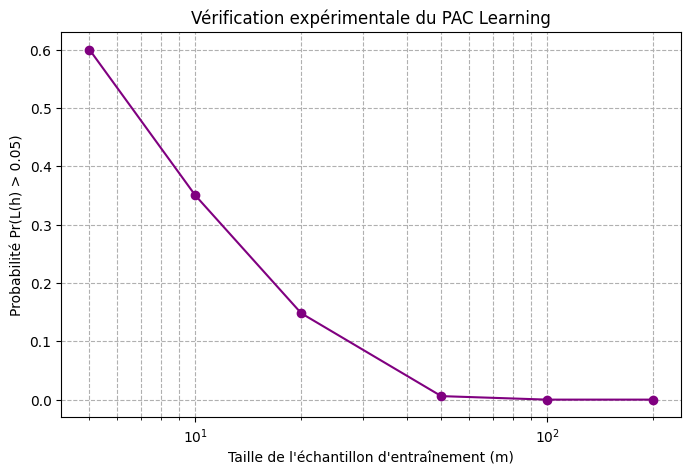

In [75]:
epsilon = 0.05
repetitions = 500
prob_estimations = []

print(f"Estimation de Pr(L(h) > {epsilon}) sur {repetitions} répétitions :")

for m in m_valeurs:
    cpt_mauvaises_hypotheeses = 0
    
    for _ in range(repetitions):
        X_train, y_train = generer_dataset(m, theta)
        best_theta, _ = algorithme_ERM(X_train, y_train)
        true_err = abs(theta - best_theta)
        if true_err > epsilon:
            cpt_mauvaises_hypotheeses += 1
            
    prob = cpt_mauvaises_hypotheeses / repetitions
    prob_estimations.append(prob)
    print(f"m = {m:3d} | Probabilité estimée : {prob:.4f}")


plt.figure(figsize=(8, 5))
plt.plot(m_valeurs, prob_estimations, marker='o', color='purple')
plt.xscale('log')
plt.xlabel("Taille de l'échantillon d'entraînement (m)")
plt.ylabel(f"Probabilité Pr(L(h) > {epsilon})")
plt.title("Vérification expérimentale du PAC Learning")
plt.grid(True, which="both", ls="--")
plt.show()


Comme le cours sur PAC l'indiquait, La probabilité d'atteindre un mauvais classifieur qui ne généralise pas bien diminue en fonction de la taille de l'echantillon m.
Dans mon code, avec un epsilon de 0.05, on obsèrve bien que pour des valeurs de faibles valeurs de mla probabilité de dépasser la marge d'erreur est élevée.
Mais dés lors que m dépasse kles 50  ,la probabilité devient extrèment faible.
Ainsi cela confirme que le modèle devient PAC (Probablement Approximativement Correct) avec une quantité de données suffisante


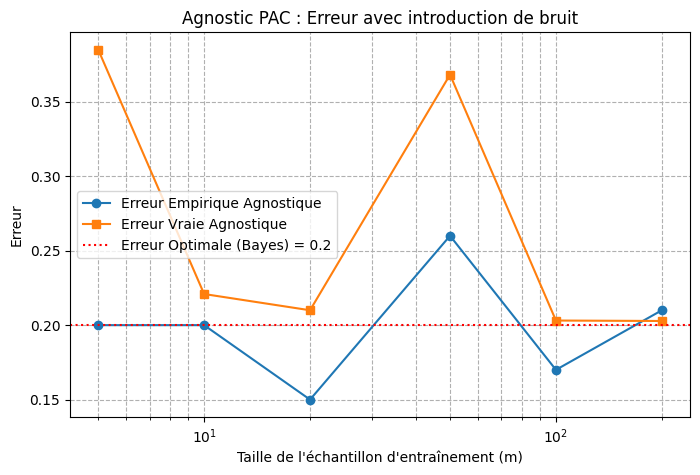

In [76]:
# Taux de bruit
eta = 0.2 

def generer_dataset_agnostic(m, theta, eta):
    """
    Génère les données et inverse aléatoirement certains labels selon la probabilité eta.
    """
    X = np.random.uniform(0, 1, m)
    # Vrais labels
    y = np.where(X > theta, 1, 0)
    
    # Introduction du bruit (Agnostic setting)
    noise = np.random.rand(m) < eta
    y = np.where(noise, 1 - y, y) # Inversion des labels bruités
    return X, y

# Grand dataset de test bruité
X_test_agn, y_test_agn = generer_dataset_agnostic(m_test, theta, eta)

empirical_errors_agn = []
true_errors_agn = []

for m in m_valeurs:
    X_train, y_train = generer_dataset_agnostic(m, theta, eta)
    
    # ERM cherche toujours à minimiser l'erreur sur le train set bruité
    best_theta_agn, emp_err_agn = algorithme_ERM(X_train, y_train)
    empirical_errors_agn.append(emp_err_agn)
    
    # Calcul de l'erreur vraie sur le test set bruité
    test_predictions_agn = np.where(X_test_agn > best_theta_agn, 1, 0)
    true_err_agn = np.mean(test_predictions_agn != y_test_agn)
    true_errors_agn.append(true_err_agn)

# Visualisation Partie 5
plt.figure(figsize=(8, 5))
plt.plot(m_valeurs, empirical_errors_agn, marker='o', label='Erreur Empirique Agnostique')
plt.plot(m_valeurs, true_errors_agn, marker='s', label='Erreur Vraie Agnostique')
# Ajout d'une ligne de référence pour le bruit de fond (la meilleure erreur possible)
plt.axhline(eta, color='red', linestyle=':', label=f'Erreur Optimale (Bayes) = {eta}')
plt.xscale('log')
plt.xlabel("Taille de l'échantillon d'entraînement (m)")
plt.ylabel("Erreur")
plt.title("Agnostic PAC : Erreur avec introduction de bruit")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

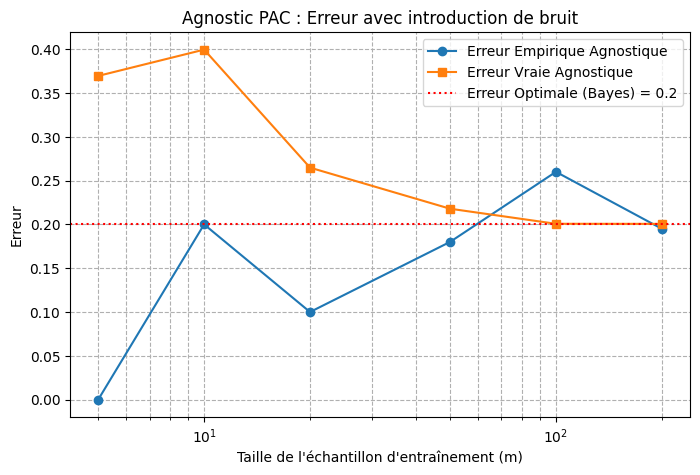

In [77]:
# Taux de bruit
eta = 0.2 

def generer_dataset_agnostique(m, theta, eta):
    """
    Génère les données et inverse aléatoirement certains labels selon la probabilité eta.
    """
    X = np.random.uniform(0, 1, m)
    y = np.where(X > theta, 1, 0)
    bruit = np.random.rand(m) < eta
    y = np.where(bruit, 1 - y, y) 
    return X, y

X_test_agn, y_test_agn = generer_dataset_agnostique(m_test, theta, eta)

erreurs_empiriques_agn = []
erreurs_veritables_agn = []

for m in m_valeurs:
    X_train, y_train = generer_dataset_agnostique(m, theta, eta)
    meilleur_theta_agn, err_emp_agn = algorithme_ERM(X_train, y_train)
    erreurs_empiriques_agn.append(err_emp_agn)

    predictions_test_agn = np.where(X_test_agn > meilleur_theta_agn, 1, 0)
    err_veritable_agn = np.mean(predictions_test_agn != y_test_agn)
    erreurs_veritables_agn.append(err_veritable_agn)
plt.figure(figsize=(8, 5))
plt.plot(m_valeurs, erreurs_empiriques_agn, marker='o', label='Erreur Empirique Agnostique')
plt.plot(m_valeurs, erreurs_veritables_agn, marker='s', label='Erreur Vraie Agnostique')
plt.axhline(eta, color='red', linestyle=':', label=f'Erreur Optimale (Bayes) = {eta}')
plt.xscale('log')
plt.xlabel("Taille de l'échantillon d'entraînement (m)")
plt.ylabel("Erreur")
plt.title("Agnostic PAC : Erreur avec introduction de bruit")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

L'introduction de bruit aléatoire dans les étiquettes modifie le comportement de l'algorithme d'apprentissage en rompant l'hypothèse de réalisabilité vue en cours. En conséquence, l'erreur empirique ne peut plus se maintenir à zéro. Bien que le modèle puisse fortuitement mémoriser un très petit échantillon d'entraînement , l'erreur empirique augmente ensuite pour se stabiliser autour du niveau de bruit introduit. Les données n'étant plus parfaitement séparables par un simple classifieur à seuil, l'algorithme ne peut plus atteindre une erreur nulle. Néanmoins, l'augmentation du nombre d'exemples d'entraînement continue d'améliorer les performances de généralisation. La courbe de l'erreur vraie diminue de manière significative. L'algorithme réduit ainsi son surapprentissage et parvient toujours à capturer la règle de classification sous-jacente malgré le bruit présent dans les étiquettes

Ces observations s'inscrivent directement dans la distinction théorique entre le modèle PAC et le modèle Agnostic PAC. Dans le cadre PAC classique, l'hypothèse de réalisabilité garantissait l'existence d'un classifieur parfait au sein de notre classe d'hypothèses, l'objectif de l'ERM étant d'atteindre une erreur absolue proche de zéro . En revanche, l'introduction du bruit nous place dans le cadre Agnostic PAC, où l'on assume qu'aucun modèle n'est parfait. L'objectif de l'apprentissage change : il ne s'agit plus d'éliminer toute erreur, mais de s'approcher au maximum de la meilleure performance atteignable au sein de notre classe d'hypothèses . Le graphique confirme visuellement ce théorème, puisque les erreurs convergent vers la limite incompressible imposée par le bruit (20%), qui correspond à l'erreur du prédicteur optimal de Bayes, plutôt que vers zéro.